# IRON-SYNC — Preprocesamiento Dataset ECG
## Modulo B: Bio-Regulacion Adaptativa — CNN-1D + LSTM

**Universidad:** UMRPSFXCH — Facultad de Tecnologia  
**Materia:** SIS-330 Desarrollo de Aplicaciones Inteligentes  
**Estudiante:** Cervantes Torres Atzel Alan  
**Docente:** Ing. Pacheco Lora Carlos Walter  

---

### Descripcion del modulo

Este cuadernillo preprocesa el dataset sintetico de senales ECG generado para IRON-SYNC.  
El objetivo es transformar los archivos CSV crudos en tensores `.npy` listos para entrenar  
la arquitectura hibrida CNN-1D + LSTM encargada de clasificar el estado fisiologico del usuario.

### Clases del dataset

| Clase   | Estado fisiologico | RR medio | RR std | FC aprox |
|---------|--------------------|----------|--------|----------|
| CALMA   | Reposo / relajacion | 820 ms  | 55 ms  | ~73 bpm  |
| TENSION | Atencion elevada   | 700 ms   | 30 ms  | ~86 bpm  |
| ESTRES  | Carga fisiologica  | 590 ms   | 10 ms  | ~102 bpm |

### Columnas de cada CSV

| Columna        | Descripcion                                      |
|----------------|--------------------------------------------------|
| time_ms        | Eje temporal en milisegundos (0 a 10000)         |
| amplitude_mV   | Amplitud cruda de la senal ECG en milivoltios    |
| amplitude_norm | Amplitud z-normalizada por muestra               |
| RR_ms          | Intervalo RR interpolado punto a punto (ms)      |
| HRV_local_ms   | Variabilidad local: |RR_i - RR_{i-1}| en ms     |
| RR_norm        | RR_ms z-normalizado por muestra                  |
| HRV_norm       | HRV_local_ms z-normalizado por muestra           |

### Metadatos en cabecera de cada CSV

Cada archivo contiene 10 lineas de comentario con `#` antes del encabezado de columnas,  
con informacion de: clase, sample_id, fs_hz, duration_s, n_points, n_beats, sdnn_ms, rmssd_ms, hr_bpm.

### Parametros del dataset

| Parametro         | Valor            |
|-------------------|------------------|
| Frecuencia Fs     | 500 Hz           |
| Duracion          | 10 s             |
| Puntos por muestra| 5000             |
| Muestras por clase| 5000             |
| Total muestras    | 15000            |
| Clases            | CALMA / TENSION / ESTRES |

## 1. Instalacion de dependencias

Verificacion e instalacion de las librerias necesarias para ejecutar el cuadernillo.

In [1]:
# Instalar dependencias si no estan presentes
# Ejecutar esta celda una sola vez y reiniciar el kernel si es necesario

import subprocess
import sys

paquetes = ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn", "joblib", "tqdm"]

for paquete in paquetes:
    try:
        __import__(paquete.replace("-", "_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", paquete])
        print(f"Instalado: {paquete}")

print("Todas las dependencias estan disponibles.")

Instalado: scikit-learn
Todas las dependencias estan disponibles.


## 2. Imports y configuracion global

Se importan todas las librerias al inicio para tener visibilidad completa de las dependencias.  
La configuracion de rutas se centraliza aqui: modificar `BASE_PATH` segun el entorno de ejecucion.

In [2]:
# --- Libreria estandar ---
import os
import re
import warnings
from pathlib import Path

# --- Computacion numerica y datos ---
import numpy as np
import pandas as pd

# --- Visualizacion ---
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- Machine learning ---
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Utilidades ---
import joblib
from tqdm import tqdm

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIGURACION GLOBAL — modificar BASE_PATH segun el entorno
# =============================================================================

BASE_PATH    = Path(r"C:/MI ECOSISTEMA/UFSX/PROYECTOS-USFX/7MO_SEMESTRE/SIS330/IRON-SYNC")
DATASET_PATH = BASE_PATH / "dataset" / "ECG"
OUTPUT_PATH  = BASE_PATH / "cuadernillos" / "preprocessed" / "ECG"
FIGURES_PATH = BASE_PATH / "cuadernillos" / "figures"

# Parametros del dataset
CLASES       = ["CALMA", "TENSION", "ESTRES"]
FS           = 500          # Hz
DURACION_S   = 10           # segundos
N_PUNTOS     = FS * DURACION_S  # 5000 puntos por muestra
RANDOM_SEED  = 42
TEST_SIZE    = 0.15
VAL_SIZE     = 0.15

# Columnas de datos (excluye time_ms)
COLS_SIGNAL  = ["amplitude_mV"]
COLS_NORM    = ["amplitude_norm"]
COLS_HRV_RAW = ["RR_ms", "HRV_local_ms"]
COLS_HRV_NORM= ["RR_norm", "HRV_norm"]
ALL_DATA_COLS= ["amplitude_mV", "amplitude_norm", "RR_ms", "HRV_local_ms", "RR_norm", "HRV_norm"]

# Colores por clase (consistentes con el generador)
COLORES = {
    "CALMA":   "#2196F3",
    "TENSION": "#FF9800",
    "ESTRES":  "#F44336"
}

# Etiquetas numericas
LABEL_MAP = {"CALMA": 0, "TENSION": 1, "ESTRES": 2}

# Semilla global
np.random.seed(RANDOM_SEED)

# Crear directorios de salida
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("Configuracion cargada correctamente.")
print(f"  Dataset : {DATASET_PATH}")
print(f"  Salida  : {OUTPUT_PATH}")
print(f"  Figuras : {FIGURES_PATH}")

Configuracion cargada correctamente.
  Dataset : C:\MI ECOSISTEMA\UFSX\PROYECTOS-USFX\7MO_SEMESTRE\SIS330\IRON-SYNC\dataset\ECG
  Salida  : C:\MI ECOSISTEMA\UFSX\PROYECTOS-USFX\7MO_SEMESTRE\SIS330\IRON-SYNC\cuadernillos\preprocessed\ECG
  Figuras : C:\MI ECOSISTEMA\UFSX\PROYECTOS-USFX\7MO_SEMESTRE\SIS330\IRON-SYNC\cuadernillos\figures


## 3. Exploracion de la estructura del dataset

Antes de cargar los datos se verifica que la estructura de carpetas sea correcta  
y se cuenta el numero de archivos CSV disponibles por clase.

Estructura esperada:
```
dataset/ECG/
    CALMA/
        0001/signal_0001.csv
        0002/signal_0002.csv
        ...
    TENSION/
        ...
    ESTRES/
        ...
```

In [3]:
# Recorrer la estructura y contar CSVs disponibles por clase

resumen_estructura = {}

for clase in CLASES:
    clase_path = DATASET_PATH / clase
    if not clase_path.exists():
        resumen_estructura[clase] = {"carpetas": 0, "csvs": 0, "estado": "NO ENCONTRADA"}
        continue

    carpetas = [d for d in clase_path.iterdir() if d.is_dir()]
    csvs     = list(clase_path.rglob("*.csv"))

    resumen_estructura[clase] = {
        "carpetas": len(carpetas),
        "csvs":     len(csvs),
        "estado":   "OK" if len(csvs) > 0 else "SIN ARCHIVOS"
    }

# Imprimir resumen
print("=" * 55)
print("  Estructura del dataset ECG")
print("=" * 55)
print(f"  {'Clase':<10} {'Carpetas':>10} {'CSVs':>8} {'Estado':>12}")
print("-" * 55)

total_csvs = 0
for clase, info in resumen_estructura.items():
    print(f"  {clase:<10} {info['carpetas']:>10,} {info['csvs']:>8,}   {info['estado']:>10}")
    total_csvs += info["csvs"]

print("-" * 55)
print(f"  {'TOTAL':<10} {'':>10} {total_csvs:>8,}")
print("=" * 55)

# Mostrar ejemplo de ruta del primer CSV de cada clase
print()
print("Ejemplo de rutas:")
for clase in CLASES:
    clase_path = DATASET_PATH / clase
    primeros   = sorted(clase_path.rglob("*.csv"))[:1]
    for p in primeros:
        print(f"  {clase}: ...{str(p)[str(p).find('ECG'):]}")

  Estructura del dataset ECG
  Clase        Carpetas     CSVs       Estado
-------------------------------------------------------
  CALMA           5,000    5,000           OK
  TENSION         5,000    5,000           OK
  ESTRES          5,000    5,000           OK
-------------------------------------------------------
  TOTAL                   15,000

Ejemplo de rutas:
  CALMA: ...ECG\CALMA\0001\signal_0001.csv
  TENSION: ...ECG\TENSION\0001\signal_0001.csv
  ESTRES: ...ECG\ESTRES\0001\signal_0001.csv


## 4. Carga del dataset

Se implementa la funcion `cargar_dataset_ecg` que recorre todas las carpetas,  
lee cada CSV y extrae tanto la senal como los metadatos HRV de las lineas de cabecera.

### Estructura de cada CSV

Las primeras 10 lineas comienzan con `#` y contienen metadatos clave:
- `sdnn_ms`: desviacion estandar de los intervalos RR — indicador de variabilidad global
- `rmssd_ms`: raiz cuadrada de la media de diferencias sucesivas al cuadrado — variabilidad de corto plazo
- `hr_bpm`: frecuencia cardiaca media derivada de RR
- `n_beats`: numero de latidos en la ventana de 10 segundos

Estos valores se usan como features escalares por muestra, complementando la senal temporal.

In [4]:
def parsear_metadatos(ruta_csv):
    """
    Lee las lineas de cabecera de un CSV del dataset ECG y extrae los metadatos.

    Parametros
    ----------
    ruta_csv : Path
        Ruta al archivo CSV.

    Retorna
    -------
    dict con claves: sdnn_ms, rmssd_ms, hr_bpm, n_beats
    """
    meta = {"sdnn_ms": np.nan, "rmssd_ms": np.nan, "hr_bpm": np.nan, "n_beats": np.nan}
    claves_buscar = ["sdnn_ms", "rmssd_ms", "hr_bpm", "n_beats"]

    with open(ruta_csv, "r") as f:
        for linea in f:
            linea = linea.strip()
            if not linea.startswith("#"):
                break  # fin de cabecera
            for clave in claves_buscar:
                if f"# {clave}=" in linea:
                    valor_str = linea.split("=")[-1].strip()
                    try:
                        meta[clave] = float(valor_str)
                    except ValueError:
                        pass
    return meta


def cargar_dataset_ecg(dataset_path, clases, max_por_clase=None):
    """
    Carga el dataset ECG completo desde la estructura de carpetas.

    Parametros
    ----------
    dataset_path  : Path
        Ruta a la carpeta raiz del dataset ECG (contiene CALMA/, TENSION/, ESTRES/).
    clases        : list of str
        Lista de nombres de clase a cargar.
    max_por_clase : int o None
        Limite de muestras por clase. None = cargar todas.

    Retorna
    -------
    X_signal  : np.ndarray, shape (n, 5000)
        Amplitud cruda en mV de cada muestra.
    X_hrv_raw : np.ndarray, shape (n, 5000, 2)
        Canales RR_ms y HRV_local_ms punto a punto.
    X_hrv_norm: np.ndarray, shape (n, 5000, 2)
        Canales RR_norm y HRV_norm punto a punto.
    X_norm    : np.ndarray, shape (n, 5000)
        Amplitud ya z-normalizada por muestra (del generador).
    meta_df   : pd.DataFrame, shape (n, 6)
        Metadatos por muestra: clase, label, sdnn_ms, rmssd_ms, hr_bpm, n_beats.
    y         : np.ndarray, shape (n,)
        Etiquetas numericas (0=CALMA, 1=TENSION, 2=ESTRES).
    """
    listas = {
        "signal":   [],
        "hrv_raw":  [],
        "hrv_norm": [],
        "norm":     [],
        "meta":     []
    }

    for clase in clases:
        clase_path = dataset_path / clase
        archivos   = sorted(clase_path.rglob("*.csv"))

        if max_por_clase is not None:
            archivos = archivos[:max_por_clase]

        label = LABEL_MAP[clase]

        for ruta in tqdm(archivos, desc=f"Cargando {clase}", unit="csv"):
            try:
                # Leer metadatos de la cabecera
                meta = parsear_metadatos(ruta)
                meta["clase"] = clase
                meta["label"] = label

                # Leer datos numericos saltando lineas con #
                df = pd.read_csv(
                    ruta,
                    comment="#",
                    usecols=["amplitude_mV", "amplitude_norm",
                             "RR_ms", "HRV_local_ms", "RR_norm", "HRV_norm"]
                )

                # Verificar longitud esperada
                if len(df) != N_PUNTOS:
                    continue

                listas["signal"].append(df["amplitude_mV"].values.astype(np.float32))
                listas["norm"].append(df["amplitude_norm"].values.astype(np.float32))
                listas["hrv_raw"].append(
                    df[["RR_ms", "HRV_local_ms"]].values.astype(np.float32)
                )
                listas["hrv_norm"].append(
                    df[["RR_norm", "HRV_norm"]].values.astype(np.float32)
                )
                listas["meta"].append(meta)

            except Exception as e:
                # Omitir archivos corruptos o incompletos
                continue

    X_signal   = np.array(listas["signal"])
    X_norm     = np.array(listas["norm"])
    X_hrv_raw  = np.array(listas["hrv_raw"])
    X_hrv_norm = np.array(listas["hrv_norm"])
    meta_df    = pd.DataFrame(listas["meta"])
    y          = meta_df["label"].values.astype(np.int64)

    return X_signal, X_hrv_raw, X_hrv_norm, X_norm, meta_df, y


# =============================================================================
# Ejecucion de la carga
# Usar max_por_clase=500 para pruebas rapidas; None para dataset completo
# =============================================================================

MAX_POR_CLASE = None   # cambiar a 500 para prueba rapida

X_signal, X_hrv_raw, X_hrv_norm, X_norm, meta_df, y = cargar_dataset_ecg(
    DATASET_PATH, CLASES, max_por_clase=MAX_POR_CLASE
)

print()
print("=" * 55)
print("  Resultado de la carga")
print("=" * 55)
print(f"  X_signal   : {X_signal.shape}    (muestras, puntos)")
print(f"  X_norm     : {X_norm.shape}    (muestras, puntos)")
print(f"  X_hrv_raw  : {X_hrv_raw.shape}  (muestras, puntos, 2 canales)")
print(f"  X_hrv_norm : {X_hrv_norm.shape}  (muestras, puntos, 2 canales)")
print(f"  y          : {y.shape}")
print(f"  meta_df    : {meta_df.shape}")
print()
print("  Distribucion de clases:")
for clase, label in LABEL_MAP.items():
    n = (y == label).sum()
    print(f"    {clase:<10}: {n:>6,} muestras")
print("=" * 55)

Cargando ESTRES: 100%|██████████| 5000/5000 [04:15<00:00, 19.54csv/s]



  Resultado de la carga
  X_signal   : (15000, 5000)    (muestras, puntos)
  X_norm     : (15000, 5000)    (muestras, puntos)
  X_hrv_raw  : (15000, 5000, 2)  (muestras, puntos, 2 canales)
  X_hrv_norm : (15000, 5000, 2)  (muestras, puntos, 2 canales)
  y          : (15000,)
  meta_df    : (15000, 6)

  Distribucion de clases:
    CALMA     :  5,000 muestras
    TENSION   :  5,000 muestras
    ESTRES    :  5,000 muestras


## 5. Verificacion de integridad

Se comprueba que no existan valores NaN, Inf ni anomalias en los arrays cargados.  
Detectar estos problemas antes del entrenamiento evita fallos silenciosos en el modelo.

In [5]:
# Verificar NaN e Inf en cada array

arrays_verificar = {
    "X_signal":   X_signal,
    "X_norm":     X_norm,
    "X_hrv_raw":  X_hrv_raw,
    "X_hrv_norm": X_hrv_norm
}

print("Verificacion de integridad de los arrays")
print("-" * 50)
todo_ok = True
for nombre, arr in arrays_verificar.items():
    nan_count = np.isnan(arr).sum()
    inf_count = np.isinf(arr).sum()
    estado    = "OK" if nan_count == 0 and inf_count == 0 else "PROBLEMA"
    if estado == "PROBLEMA":
        todo_ok = False
    print(f"  {nombre:<15}  NaN: {nan_count:>6}   Inf: {inf_count:>6}   [{estado}]")

print()
if todo_ok:
    print("Todos los arrays pasan la verificacion de integridad.")
else:
    print("Se detectaron problemas. Revisar las muestras afectadas antes de continuar.")

# Verificar metadatos HRV
print()
print("Resumen estadistico de metadatos HRV (meta_df):")
print(meta_df[["sdnn_ms", "rmssd_ms", "hr_bpm", "n_beats"]].describe().round(2).to_string())

Verificacion de integridad de los arrays
--------------------------------------------------
  X_signal         NaN:      0   Inf:      0   [OK]
  X_norm           NaN:      0   Inf:      0   [OK]
  X_hrv_raw        NaN:      0   Inf:      0   [OK]
  X_hrv_norm       NaN:      0   Inf:      0   [OK]

Todos los arrays pasan la verificacion de integridad.

Resumen estadistico de metadatos HRV (meta_df):
        sdnn_ms  rmssd_ms    hr_bpm   n_beats
count  15000.00  15000.00  15000.00  15000.00
mean      29.60     43.26     86.86     13.81
std       18.49     28.09     11.72      1.83
min        3.60      5.02     68.20     11.00
25%       10.66     15.83     74.10     12.00
50%       27.79     39.70     85.70     14.00
75%       43.36     62.08    101.40     16.00
max      102.57    195.15    103.10     17.00


## 6. Analisis exploratorio — Senales ECG

Se visualizan tres senales representativas por clase para confirmar visualmente  
que las diferencias morfologicas y de ritmo entre CALMA, TENSION y ESTRES  
son coherentes con los parametros del generador.

La senal CALMA debe mostrar ciclos mas espaciados y amplios; la de ESTRES  
ciclos mas rapidos y comprimidos. Esta inspeccion visual es el primer paso  
de validacion del dataset antes de cualquier procesamiento.

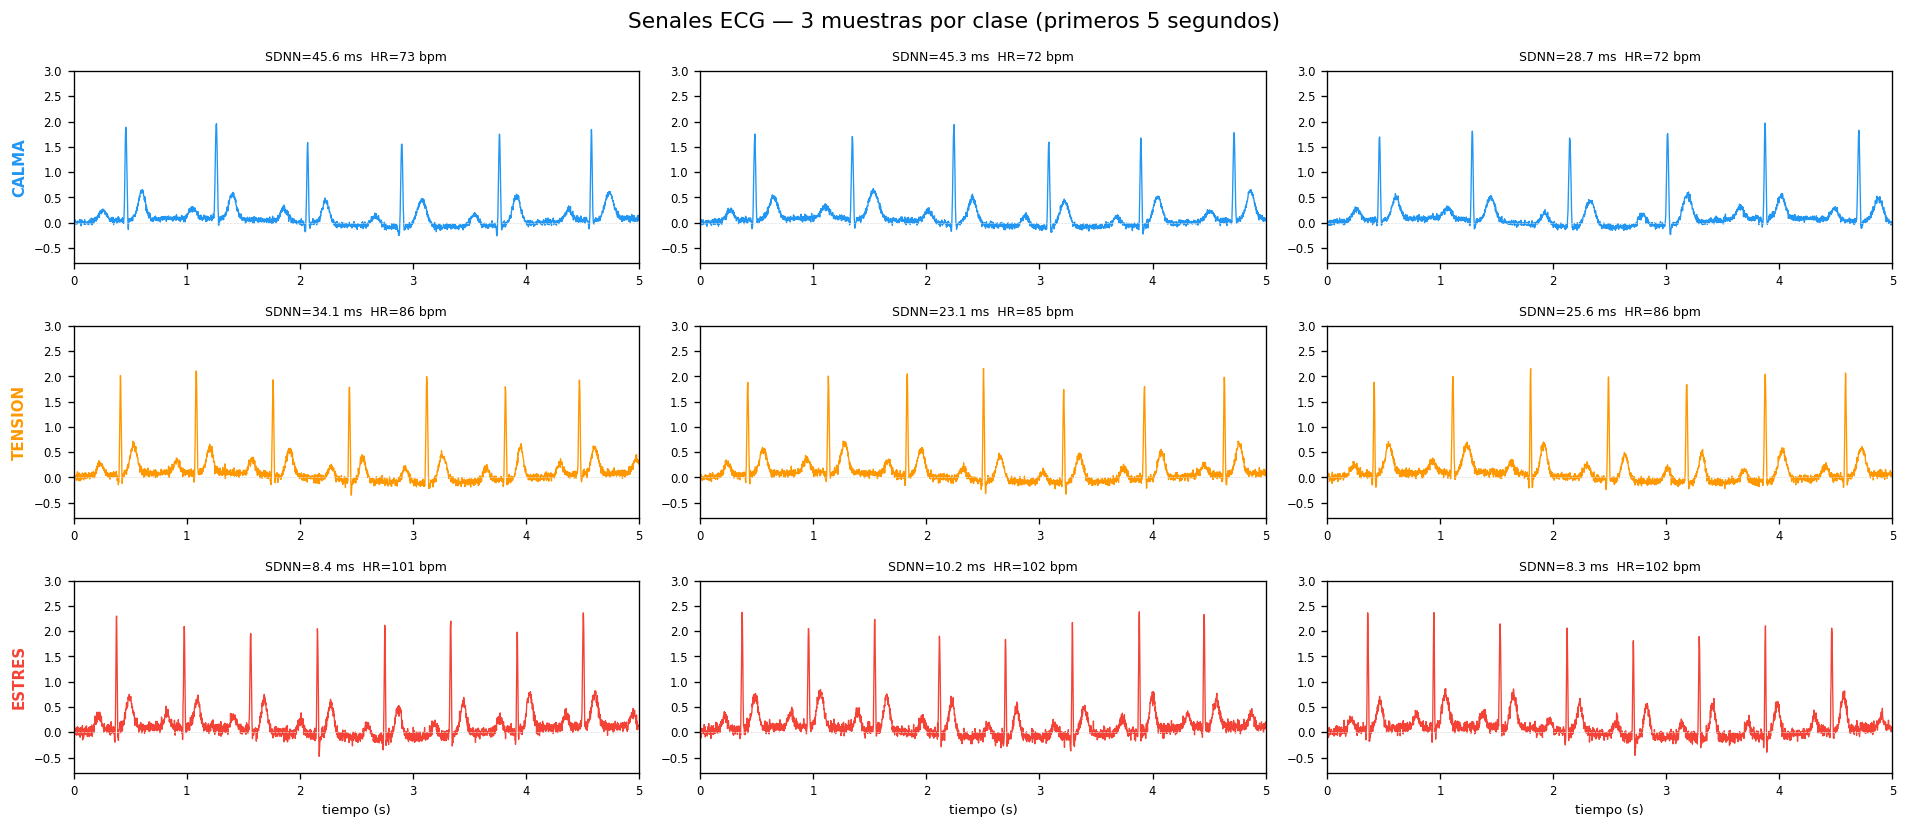

Figura guardada: ECG_senales_por_clase.png


In [6]:
# Visualizar 3 senales por clase — primeros 5 segundos (2500 puntos)

N_MOSTRAR  = 3
PUNTOS_5S  = FS * 5   # 2500 puntos = 5 segundos
t_eje      = np.linspace(0, 5, PUNTOS_5S)

fig, axes = plt.subplots(len(CLASES), N_MOSTRAR, figsize=(16, 7), dpi=120)
fig.suptitle("Senales ECG — 3 muestras por clase (primeros 5 segundos)", fontsize=13)

for fila, clase in enumerate(CLASES):
    indices_clase = np.where(y == LABEL_MAP[clase])[0]
    muestras_idx  = np.random.default_rng(RANDOM_SEED).choice(indices_clase, N_MOSTRAR, replace=False)

    for col, idx in enumerate(muestras_idx):
        ax = axes[fila][col]
        ax.plot(t_eje, X_signal[idx, :PUNTOS_5S], color=COLORES[clase], linewidth=0.8)
        ax.axhline(0, color="#DDDDDD", linewidth=0.4, linestyle="--")
        ax.set_xlim(0, 5)
        ax.set_ylim(-0.8, 3.0)

        titulo_meta = (
            f"SDNN={meta_df.iloc[idx]['sdnn_ms']:.1f} ms  "
            f"HR={meta_df.iloc[idx]['hr_bpm']:.0f} bpm"
        )
        ax.set_title(titulo_meta, fontsize=7.5)

        if col == 0:
            ax.set_ylabel(clase, fontsize=9, fontweight="bold", color=COLORES[clase])
        if fila == len(CLASES) - 1:
            ax.set_xlabel("tiempo (s)", fontsize=8)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "ECG_senales_por_clase.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figura guardada: ECG_senales_por_clase.png")

## 7. Analisis exploratorio — Metricas HRV

SDNN y RMSSD son los dos indicadores mas robustos del estado del sistema nervioso autonomo.

- **SDNN** mide la variabilidad global de los intervalos RR: valores altos indican predominio  
  parasimpatico (calma), valores bajos indican predominio simpatico (estres).
- **RMSSD** mide la variabilidad de corto plazo: refleja especificamente la actividad vagal.
- La frecuencia cardiaca (HR) es inversamente proporcional al intervalo RR medio.

Si el dataset es correcto, los tres grupos deben separarse claramente en el espacio SDNN x RMSSD.

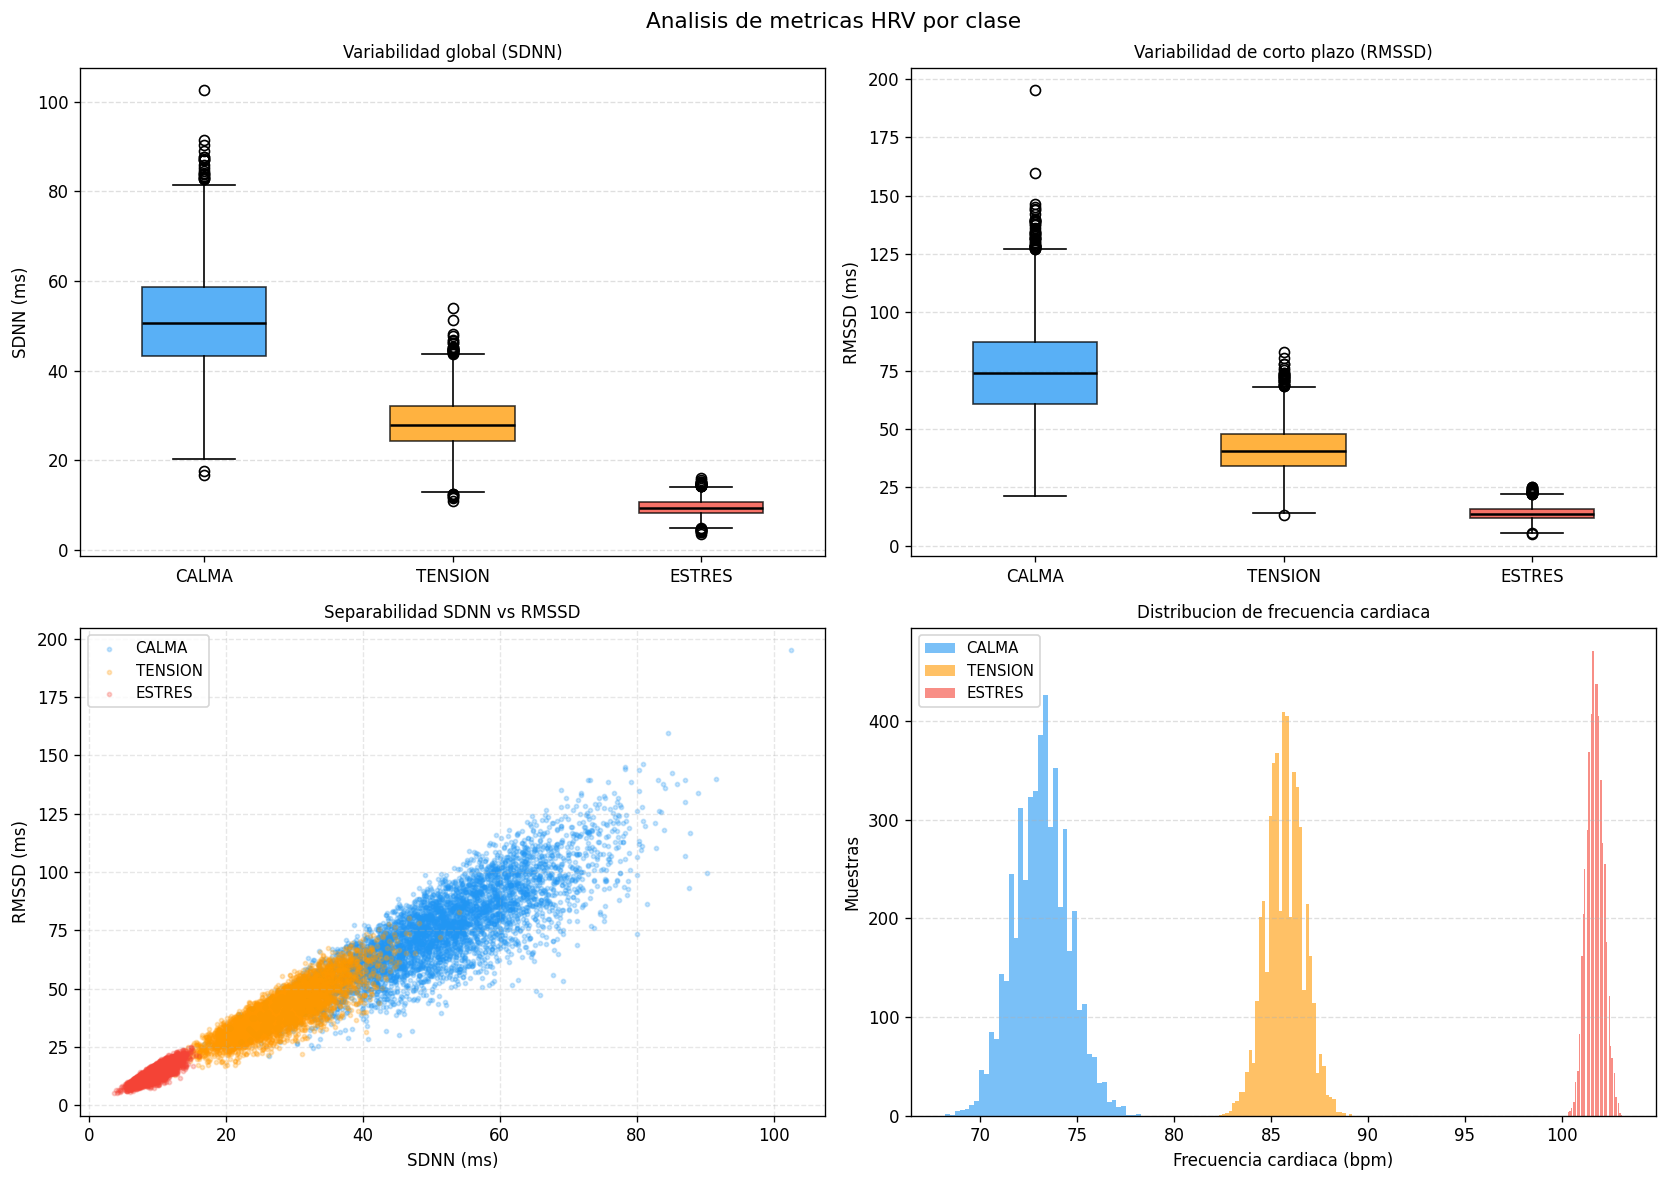

Estadisticas descriptivas de metricas HRV por clase:

  CALMA
       sdnn_ms  rmssd_ms   hr_bpm
count  5000.00   5000.00  5000.00
mean     51.06     74.86    73.17
std      11.16     19.69     1.43
min      16.70     21.06    68.20
25%      43.21     60.72    72.20
50%      50.72     73.90    73.20
75%      58.63     87.22    74.10
max     102.57    195.15    78.30

  TENSION
       sdnn_ms  rmssd_ms   hr_bpm
count  5000.00   5000.00  5000.00
mean     28.21     41.11    85.72
std       5.70      9.99     0.97
min      10.94     13.09    82.30
25%      24.23     33.99    85.10
50%      27.96     40.39    85.70
75%      32.03     47.67    86.40
max      54.02     82.91    89.20

  ESTRES
       sdnn_ms  rmssd_ms   hr_bpm
count  5000.00   5000.00  5000.00
mean      9.52     13.82   101.69
std       1.75      3.06     0.44
min       3.60      5.02   100.30
25%       8.33     11.63   101.40
50%       9.46     13.67   101.70
75%      10.66     15.83   102.00
max      16.04     25.10   103.10

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=120)
fig.suptitle("Analisis de metricas HRV por clase", fontsize=13)

# --- Subplot 1: Boxplot SDNN ---
ax = axes[0][0]
datos_sdnn = [meta_df[meta_df["clase"] == c]["sdnn_ms"].values for c in CLASES]
bp = ax.boxplot(datos_sdnn, patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=1.5))
for patch, clase in zip(bp["boxes"], CLASES):
    patch.set_facecolor(COLORES[clase])
    patch.set_alpha(0.75)
ax.set_xticklabels(CLASES, fontsize=10)
ax.set_ylabel("SDNN (ms)", fontsize=10)
ax.set_title("Variabilidad global (SDNN)", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# --- Subplot 2: Boxplot RMSSD ---
ax = axes[0][1]
datos_rmssd = [meta_df[meta_df["clase"] == c]["rmssd_ms"].values for c in CLASES]
bp2 = ax.boxplot(datos_rmssd, patch_artist=True, widths=0.5,
                 medianprops=dict(color="black", linewidth=1.5))
for patch, clase in zip(bp2["boxes"], CLASES):
    patch.set_facecolor(COLORES[clase])
    patch.set_alpha(0.75)
ax.set_xticklabels(CLASES, fontsize=10)
ax.set_ylabel("RMSSD (ms)", fontsize=10)
ax.set_title("Variabilidad de corto plazo (RMSSD)", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# --- Subplot 3: Scatter SDNN vs RMSSD ---
ax = axes[1][0]
for clase in CLASES:
    sub = meta_df[meta_df["clase"] == clase]
    ax.scatter(sub["sdnn_ms"], sub["rmssd_ms"],
               color=COLORES[clase], alpha=0.25, s=6, label=clase)
ax.set_xlabel("SDNN (ms)", fontsize=10)
ax.set_ylabel("RMSSD (ms)", fontsize=10)
ax.set_title("Separabilidad SDNN vs RMSSD", fontsize=10)
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.3)

# --- Subplot 4: Distribucion HR ---
ax = axes[1][1]
for clase in CLASES:
    sub = meta_df[meta_df["clase"] == clase]["hr_bpm"]
    ax.hist(sub, bins=40, color=COLORES[clase], alpha=0.6, label=clase)
ax.set_xlabel("Frecuencia cardiaca (bpm)", fontsize=10)
ax.set_ylabel("Muestras", fontsize=10)
ax.set_title("Distribucion de frecuencia cardiaca", fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "ECG_hrv_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

# Tabla estadistica
print("Estadisticas descriptivas de metricas HRV por clase:")
print()
for clase in CLASES:
    sub = meta_df[meta_df["clase"] == clase][["sdnn_ms", "rmssd_ms", "hr_bpm"]]
    print(f"  {clase}")
    print(sub.describe().round(2).to_string(index=True))
    print()

## 8. Extraccion de features escalares por muestra

Se construye una matriz de features globales donde cada fila representa una muestra  
y cada columna es un indicador fisiologico derivado de los metadatos HRV.

Estas features complementan la senal temporal en modelos que requieren  
entrada tabular o en capas densas finales de la arquitectura CNN-1D + LSTM.

| Feature            | Descripcion                                            |
|--------------------|--------------------------------------------------------|
| sdnn_ms            | Variabilidad global de intervalos RR                   |
| rmssd_ms           | Variabilidad de corto plazo (actividad vagal)          |
| hr_bpm             | Frecuencia cardiaca media                              |
| n_beats            | Numero de latidos en la ventana de 10 s               |
| sdnn_rmssd_ratio   | Ratio simpatico/parasimpatico aproximado               |

In [8]:
def extraer_features_ecg(meta_df):
    """
    Construye la matriz de features escalares a partir de los metadatos HRV.

    Parametros
    ----------
    meta_df : pd.DataFrame
        DataFrame con columnas sdnn_ms, rmssd_ms, hr_bpm, n_beats.

    Retorna
    -------
    X_feat : np.ndarray, shape (n_muestras, 5)
    nombres : list of str
        Nombres de las features en el mismo orden.
    """
    df = meta_df.copy()

    # Ratio sdnn/rmssd — valores altos indican mayor tono simpatico
    df["sdnn_rmssd_ratio"] = df["sdnn_ms"] / (df["rmssd_ms"] + 1e-8)

    nombres = ["sdnn_ms", "rmssd_ms", "hr_bpm", "n_beats", "sdnn_rmssd_ratio"]
    X_feat  = df[nombres].values.astype(np.float32)

    return X_feat, nombres


X_features, nombres_features = extraer_features_ecg(meta_df)

print(f"Matriz de features escalares: {X_features.shape}")
print(f"Features: {nombres_features}")
print()

# Verificar valores invalidos
nan_feat = np.isnan(X_features).sum()
inf_feat = np.isinf(X_features).sum()
print(f"NaN en features: {nan_feat}")
print(f"Inf en features: {inf_feat}")

if nan_feat > 0 or inf_feat > 0:
    # Reemplazar con mediana de la columna si hay valores invalidos
    for col_idx in range(X_features.shape[1]):
        col = X_features[:, col_idx]
        mediana = np.nanmedian(col[np.isfinite(col)])
        mascaras = ~np.isfinite(col)
        X_features[col_idx, mascaras] = mediana
    print("Valores invalidos reemplazados por mediana de columna.")

# Correlacion de features con la etiqueta
df_feat = pd.DataFrame(X_features, columns=nombres_features)
df_feat["label"] = y
print()
print("Correlacion de cada feature con la etiqueta numerica:")
print(df_feat.corr()["label"][nombres_features].round(4).to_string())

Matriz de features escalares: (15000, 5)
Features: ['sdnn_ms', 'rmssd_ms', 'hr_bpm', 'n_beats', 'sdnn_rmssd_ratio']

NaN en features: 0
Inf en features: 0

Correlacion de cada feature con la etiqueta numerica:
sdnn_ms            -0.9171
rmssd_ms           -0.8873
hr_bpm              0.9938
n_beats             0.9808
sdnn_rmssd_ratio    0.0077


## 9. Construccion del tensor multicanal para CNN-1D + LSTM

La arquitectura CNN-1D + LSTM espera como entrada un tensor de forma `(n, puntos, canales)`.  
Se apilan 4 canales temporales por muestra:

| Canal | Fuente        | Descripcion                                  |
|-------|---------------|----------------------------------------------|
| 0     | amplitude_mV  | Senal ECG cruda en mV (principal)            |
| 1     | amplitude_norm| Senal ECG z-normalizada por el generador     |
| 2     | RR_ms         | Intervalo RR punto a punto                   |
| 3     | HRV_local_ms  | Variabilidad local punto a punto             |

Los canales RR_norm y HRV_norm del generador ya estan normalizados por muestra  
(z-score interno), por lo que se usan en la etapa de normalizacion global posterior.

In [9]:
# Apilar los 4 canales temporales en un unico tensor

# Canal 0: amplitude_mV    shape (n, 5000)
# Canal 1: amplitude_norm  shape (n, 5000)
# Canal 2: RR_ms           shape (n, 5000)   <- X_hrv_raw[:, :, 0]
# Canal 3: HRV_local_ms    shape (n, 5000)   <- X_hrv_raw[:, :, 1]

canal_signal = X_signal[:, :, np.newaxis]      # (n, 5000, 1)
canal_norm   = X_norm[:, :, np.newaxis]        # (n, 5000, 1)
canal_rr     = X_hrv_raw[:, :, 0:1]           # (n, 5000, 1)
canal_hrv    = X_hrv_raw[:, :, 1:2]           # (n, 5000, 1)

X_tensor = np.concatenate([canal_signal, canal_norm, canal_rr, canal_hrv], axis=2)

print(f"Tensor multicanal: {X_tensor.shape}  (muestras, puntos, canales)")
print()

# Verificar rango de valores por canal
for i, nombre in enumerate(["amplitude_mV", "amplitude_norm", "RR_ms", "HRV_local_ms"]):
    canal = X_tensor[:, :, i]
    print(f"  Canal {i} [{nombre:<15}]  "
          f"min={canal.min():.3f}  max={canal.max():.3f}  "
          f"mean={canal.mean():.3f}  std={canal.std():.3f}")

Tensor multicanal: (15000, 5000, 4)  (muestras, puntos, canales)

  Canal 0 [amplitude_mV   ]  min=-0.656  max=2.649  mean=0.127  std=0.284
  Canal 1 [amplitude_norm ]  min=-2.544  max=8.192  mean=0.000  std=1.000
  Canal 2 [RR_ms          ]  min=541.430  max=1045.640  mean=704.227  std=101.448
  Canal 3 [HRV_local_ms   ]  min=0.000  max=363.320  mean=33.999  std=37.204


## 10. Division del dataset — Train / Validacion / Test

Se realiza una division estratificada en tres conjuntos:

- **Train (70%)**: datos usados para ajustar los pesos del modelo.
- **Validacion (15%)**: datos usados para monitorear el entrenamiento y ajustar hiperparametros.
- **Test (15%)**: datos reservados para la evaluacion final; no se usan durante el entrenamiento.

La estratificacion garantiza que la proporcion de clases se mantenga en los tres conjuntos.  
La semilla fija asegura reproducibilidad.

  Division del dataset
  Conjunto      Muestras  Distribucion de clases
-------------------------------------------------------
  Train           10,500  CALMA:3500  TENSION:3500  ESTRES:3500
  Validacion       2,250  CALMA:750  TENSION:750  ESTRES:750
  Test             2,250  CALMA:750  TENSION:750  ESTRES:750


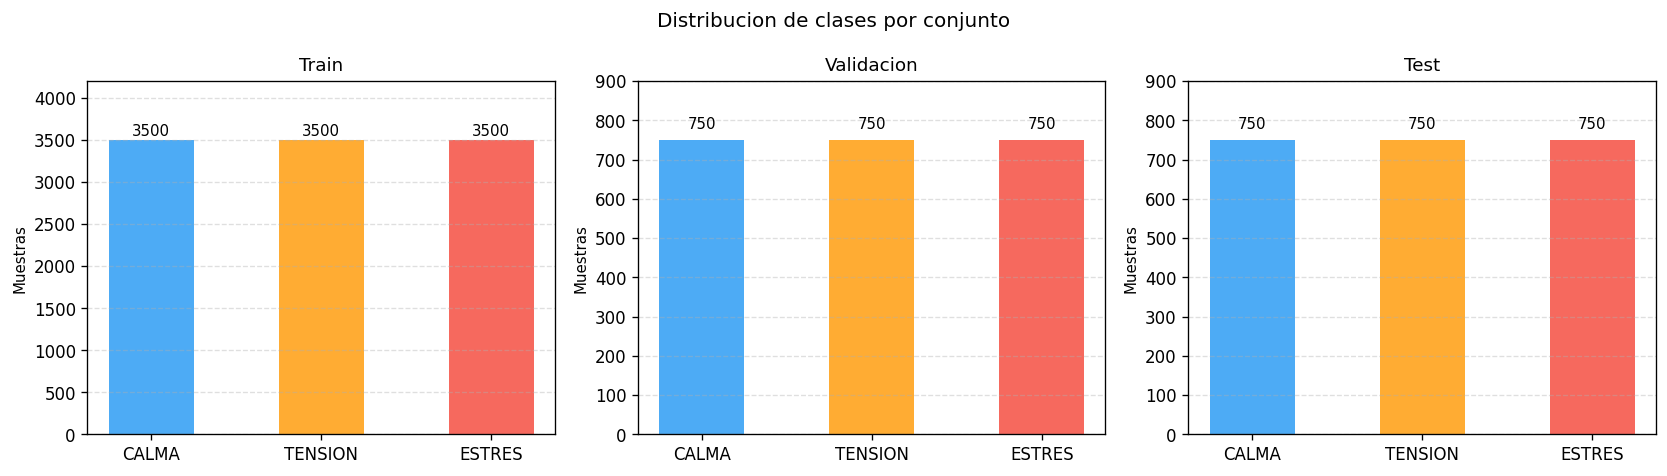

In [10]:
# Split estratificado: primero separar test, luego val del resto

indices = np.arange(len(y))

# Paso 1: separar test
idx_trainval, idx_test = train_test_split(
    indices,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_SEED
)

# Paso 2: separar val del bloque trainval
# val_size relativo al total original para mantener 15%
val_size_relativo = VAL_SIZE / (1.0 - TEST_SIZE)

idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=val_size_relativo,
    stratify=y[idx_trainval],
    random_state=RANDOM_SEED
)

# Crear subconjuntos para el tensor y las features
X_tensor_train = X_tensor[idx_train]
X_tensor_val   = X_tensor[idx_val]
X_tensor_test  = X_tensor[idx_test]

X_signal_train = X_signal[idx_train]
X_signal_val   = X_signal[idx_val]
X_signal_test  = X_signal[idx_test]

X_feat_train   = X_features[idx_train]
X_feat_val     = X_features[idx_val]
X_feat_test    = X_features[idx_test]

y_train        = y[idx_train]
y_val          = y[idx_val]
y_test         = y[idx_test]

meta_train     = meta_df.iloc[idx_train].reset_index(drop=True)
meta_val       = meta_df.iloc[idx_val].reset_index(drop=True)
meta_test      = meta_df.iloc[idx_test].reset_index(drop=True)

# Resumen de splits
print("=" * 55)
print("  Division del dataset")
print("=" * 55)
print(f"  {'Conjunto':<12} {'Muestras':>9}  Distribucion de clases")
print("-" * 55)

for nombre, y_sub in [("Train", y_train), ("Validacion", y_val), ("Test", y_test)]:
    total = len(y_sub)
    dist  = "  ".join([f"{c}:{(y_sub==v).sum()}" for c, v in LABEL_MAP.items()])
    print(f"  {nombre:<12} {total:>9,}  {dist}")

print("=" * 55)

# Visualizacion de distribucion
fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=120)
fig.suptitle("Distribucion de clases por conjunto", fontsize=12)

for ax, (nombre, y_sub) in zip(axes, [("Train", y_train), ("Validacion", y_val), ("Test", y_test)]):
    conteos = [(y_sub == v).sum() for v in LABEL_MAP.values()]
    barras  = ax.bar(CLASES, conteos, color=[COLORES[c] for c in CLASES], alpha=0.8, width=0.5)
    ax.set_title(nombre, fontsize=11)
    ax.set_ylabel("Muestras", fontsize=9)
    ax.set_ylim(0, max(conteos) * 1.2)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    for barra, val in zip(barras, conteos):
        ax.text(barra.get_x() + barra.get_width() / 2, val + 20,
                str(val), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "ECG_split_distribucion.png", dpi=120, bbox_inches="tight")
plt.show()

## 11. Normalizacion

Se aplica normalizacion estandar (z-score) de forma independiente a:

1. **Canal 0 del tensor (amplitude_mV)**: el unico canal que no fue normalizado  
   por el generador. Se ajusta un `StandardScaler` con los datos de train y  
   se aplica a val y test. Los demas canales ya vienen normalizados.

2. **Features escalares (X_features)**: normalizacion independiente con su propio scaler.

### Regla fundamental

> El scaler se ajusta **unicamente con los datos de train**.  
> Aplicarlo a val o test antes de este paso constituye *data leakage* y  
> produciria metricas de validacion artificialmente optimistas.

Los scalers se guardan en disco para poder aplicarlos en inferencia con datos nuevos.

Scalers guardados:
  C:\MI ECOSISTEMA\UFSX\PROYECTOS-USFX\7MO_SEMESTRE\SIS330\IRON-SYNC\cuadernillos\preprocessed\ECG\scaler_ecg_signal.pkl
  C:\MI ECOSISTEMA\UFSX\PROYECTOS-USFX\7MO_SEMESTRE\SIS330\IRON-SYNC\cuadernillos\preprocessed\ECG\scaler_ecg_signal_raw.pkl
  C:\MI ECOSISTEMA\UFSX\PROYECTOS-USFX\7MO_SEMESTRE\SIS330\IRON-SYNC\cuadernillos\preprocessed\ECG\scaler_ecg_features.pkl

Rango del canal amplitude_mV despues de normalizar:
  Train     mean=0.0000  std=1.0000  min=-2.75  max=8.83
  Val       mean=-0.0005  std=0.9996  min=-2.62  max=8.79
  Test      mean=-0.0008  std=0.9992  min=-2.55  max=8.87


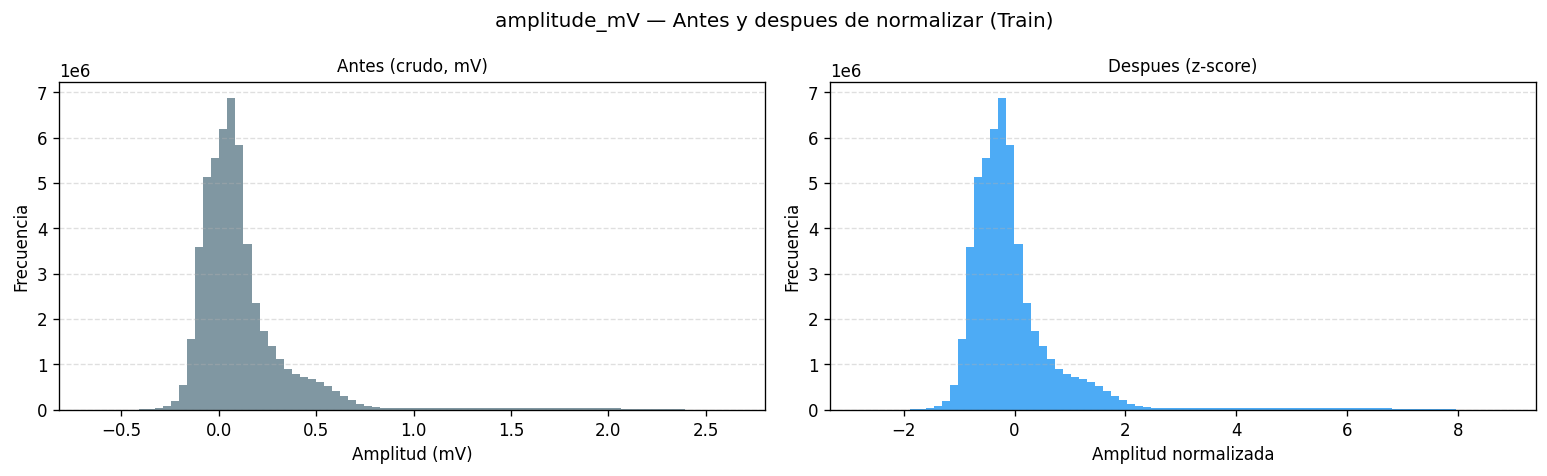

In [11]:
# --- Normalizacion del canal amplitude_mV ---

# El tensor tiene shape (n, 5000, 4). Canal 0 = amplitude_mV
# StandardScaler sobre la dimension de puntos requiere reshapear: (n*5000, 1)

scaler_signal = StandardScaler()

# Ajustar con train
n_train = X_tensor_train.shape[0]
n_val   = X_tensor_val.shape[0]
n_test  = X_tensor_test.shape[0]

train_flat = X_tensor_train[:, :, 0].reshape(-1, 1)
scaler_signal.fit(train_flat)

# Aplicar a los tres conjuntos (solo canal 0)
X_tensor_train[:, :, 0] = scaler_signal.transform(
    X_tensor_train[:, :, 0].reshape(-1, 1)
).reshape(n_train, N_PUNTOS)

X_tensor_val[:, :, 0] = scaler_signal.transform(
    X_tensor_val[:, :, 0].reshape(-1, 1)
).reshape(n_val, N_PUNTOS)

X_tensor_test[:, :, 0] = scaler_signal.transform(
    X_tensor_test[:, :, 0].reshape(-1, 1)
).reshape(n_test, N_PUNTOS)

# --- Normalizacion de X_signal (canal crudo independiente) ---

scaler_signal_raw = StandardScaler()
X_signal_train_n  = scaler_signal_raw.fit_transform(X_signal_train.reshape(-1, 1)).reshape(n_train, N_PUNTOS)
X_signal_val_n    = scaler_signal_raw.transform(X_signal_val.reshape(-1, 1)).reshape(n_val, N_PUNTOS)
X_signal_test_n   = scaler_signal_raw.transform(X_signal_test.reshape(-1, 1)).reshape(n_test, N_PUNTOS)

# --- Normalizacion de features escalares ---

scaler_features = StandardScaler()
X_feat_train_n  = scaler_features.fit_transform(X_feat_train)
X_feat_val_n    = scaler_features.transform(X_feat_val)
X_feat_test_n   = scaler_features.transform(X_feat_test)

# Guardar scalers
joblib.dump(scaler_signal,     OUTPUT_PATH / "scaler_ecg_signal.pkl")
joblib.dump(scaler_signal_raw, OUTPUT_PATH / "scaler_ecg_signal_raw.pkl")
joblib.dump(scaler_features,   OUTPUT_PATH / "scaler_ecg_features.pkl")

print("Scalers guardados:")
print(f"  {OUTPUT_PATH / 'scaler_ecg_signal.pkl'}")
print(f"  {OUTPUT_PATH / 'scaler_ecg_signal_raw.pkl'}")
print(f"  {OUTPUT_PATH / 'scaler_ecg_features.pkl'}")

# Verificar rango despues de normalizar
print()
print("Rango del canal amplitude_mV despues de normalizar:")
for nombre, arr in [("Train", X_tensor_train), ("Val", X_tensor_val), ("Test", X_tensor_test)]:
    c = arr[:, :, 0]
    print(f"  {nombre:<8}  mean={c.mean():.4f}  std={c.std():.4f}  min={c.min():.2f}  max={c.max():.2f}")

# Visualizacion antes vs despues
fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=120)
fig.suptitle("amplitude_mV — Antes y despues de normalizar (Train)", fontsize=12)

axes[0].hist(X_signal_train.flatten(), bins=80, color="#607D8B", alpha=0.8)
axes[0].set_title("Antes (crudo, mV)", fontsize=10)
axes[0].set_xlabel("Amplitud (mV)")
axes[0].set_ylabel("Frecuencia")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].hist(X_signal_train_n.flatten(), bins=80, color="#2196F3", alpha=0.8)
axes[1].set_title("Despues (z-score)", fontsize=10)
axes[1].set_xlabel("Amplitud normalizada")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "ECG_normalizacion.png", dpi=120, bbox_inches="tight")
plt.show()

## 12. Guardado de arrays procesados

Se guardan todos los tensores y arrays en formato `.npy` y los DataFrames de  
metadatos en formato `.csv`. Estos archivos son la entrada directa al script  
de entrenamiento de la red CNN-1D + LSTM.

### Archivos generados

| Archivo                    | Shape              | Descripcion                         |
|----------------------------|--------------------|-------------------------------------|
| X_tensor_train.npy         | (n, 5000, 4)       | Tensor 4 canales — conjunto train   |
| X_tensor_val.npy           | (n, 5000, 4)       | Tensor 4 canales — conjunto val     |
| X_tensor_test.npy          | (n, 5000, 4)       | Tensor 4 canales — conjunto test    |
| X_signal_train.npy         | (n, 5000)          | Senal cruda normalizada — train     |
| X_feat_train.npy           | (n, 5)             | Features escalares — train          |
| y_train.npy                | (n,)               | Etiquetas — train                   |
| meta_train.csv             | (n, 6)             | Metadatos HRV — train               |
| scaler_ecg_signal.pkl      | —                  | Scaler del canal amplitude_mV       |
| scaler_ecg_features.pkl    | —                  | Scaler de features escalares        |

In [12]:
# Guardar tensores

np.save(OUTPUT_PATH / "X_tensor_train.npy", X_tensor_train)
np.save(OUTPUT_PATH / "X_tensor_val.npy",   X_tensor_val)
np.save(OUTPUT_PATH / "X_tensor_test.npy",  X_tensor_test)

np.save(OUTPUT_PATH / "X_signal_train.npy", X_signal_train_n)
np.save(OUTPUT_PATH / "X_signal_val.npy",   X_signal_val_n)
np.save(OUTPUT_PATH / "X_signal_test.npy",  X_signal_test_n)

np.save(OUTPUT_PATH / "X_feat_train.npy",   X_feat_train_n)
np.save(OUTPUT_PATH / "X_feat_val.npy",     X_feat_val_n)
np.save(OUTPUT_PATH / "X_feat_test.npy",    X_feat_test_n)

np.save(OUTPUT_PATH / "y_train.npy",        y_train)
np.save(OUTPUT_PATH / "y_val.npy",          y_val)
np.save(OUTPUT_PATH / "y_test.npy",         y_test)

# Guardar metadatos HRV como CSV
meta_train.to_csv(OUTPUT_PATH / "meta_train.csv", index=False)
meta_val.to_csv(OUTPUT_PATH / "meta_val.csv",     index=False)
meta_test.to_csv(OUTPUT_PATH / "meta_test.csv",   index=False)

# Resumen de archivos guardados
print("Archivos guardados en:")
print(f"  {OUTPUT_PATH}")
print()
print(f"  {'Archivo':<35} {'Shape / Filas':>20}")
print("-" * 58)

archivos_npy = [
    ("X_tensor_train.npy",  X_tensor_train.shape),
    ("X_tensor_val.npy",    X_tensor_val.shape),
    ("X_tensor_test.npy",   X_tensor_test.shape),
    ("X_signal_train.npy",  X_signal_train_n.shape),
    ("X_signal_val.npy",    X_signal_val_n.shape),
    ("X_signal_test.npy",   X_signal_test_n.shape),
    ("X_feat_train.npy",    X_feat_train_n.shape),
    ("X_feat_val.npy",      X_feat_val_n.shape),
    ("X_feat_test.npy",     X_feat_test_n.shape),
    ("y_train.npy",         y_train.shape),
    ("y_val.npy",           y_val.shape),
    ("y_test.npy",          y_test.shape),
]

for nombre, forma in archivos_npy:
    print(f"  {nombre:<35} {str(forma):>20}")

print()
print("Metadatos HRV:")
for nombre, df_sub in [("meta_train.csv", meta_train), ("meta_val.csv", meta_val), ("meta_test.csv", meta_test)]:
    print(f"  {nombre:<35} {len(df_sub):>6} filas")

Archivos guardados en:
  C:\MI ECOSISTEMA\UFSX\PROYECTOS-USFX\7MO_SEMESTRE\SIS330\IRON-SYNC\cuadernillos\preprocessed\ECG

  Archivo                                    Shape / Filas
----------------------------------------------------------
  X_tensor_train.npy                      (10500, 5000, 4)
  X_tensor_val.npy                         (2250, 5000, 4)
  X_tensor_test.npy                        (2250, 5000, 4)
  X_signal_train.npy                         (10500, 5000)
  X_signal_val.npy                            (2250, 5000)
  X_signal_test.npy                           (2250, 5000)
  X_feat_train.npy                              (10500, 5)
  X_feat_val.npy                                 (2250, 5)
  X_feat_test.npy                                (2250, 5)
  y_train.npy                                     (10500,)
  y_val.npy                                        (2250,)
  y_test.npy                                       (2250,)

Metadatos HRV:
  meta_train.csv                   

## 13. Dashboard de verificacion final

Visualizacion de conjunto para confirmar que el preprocesamiento es correcto  
antes de pasar al entrenamiento del modelo.

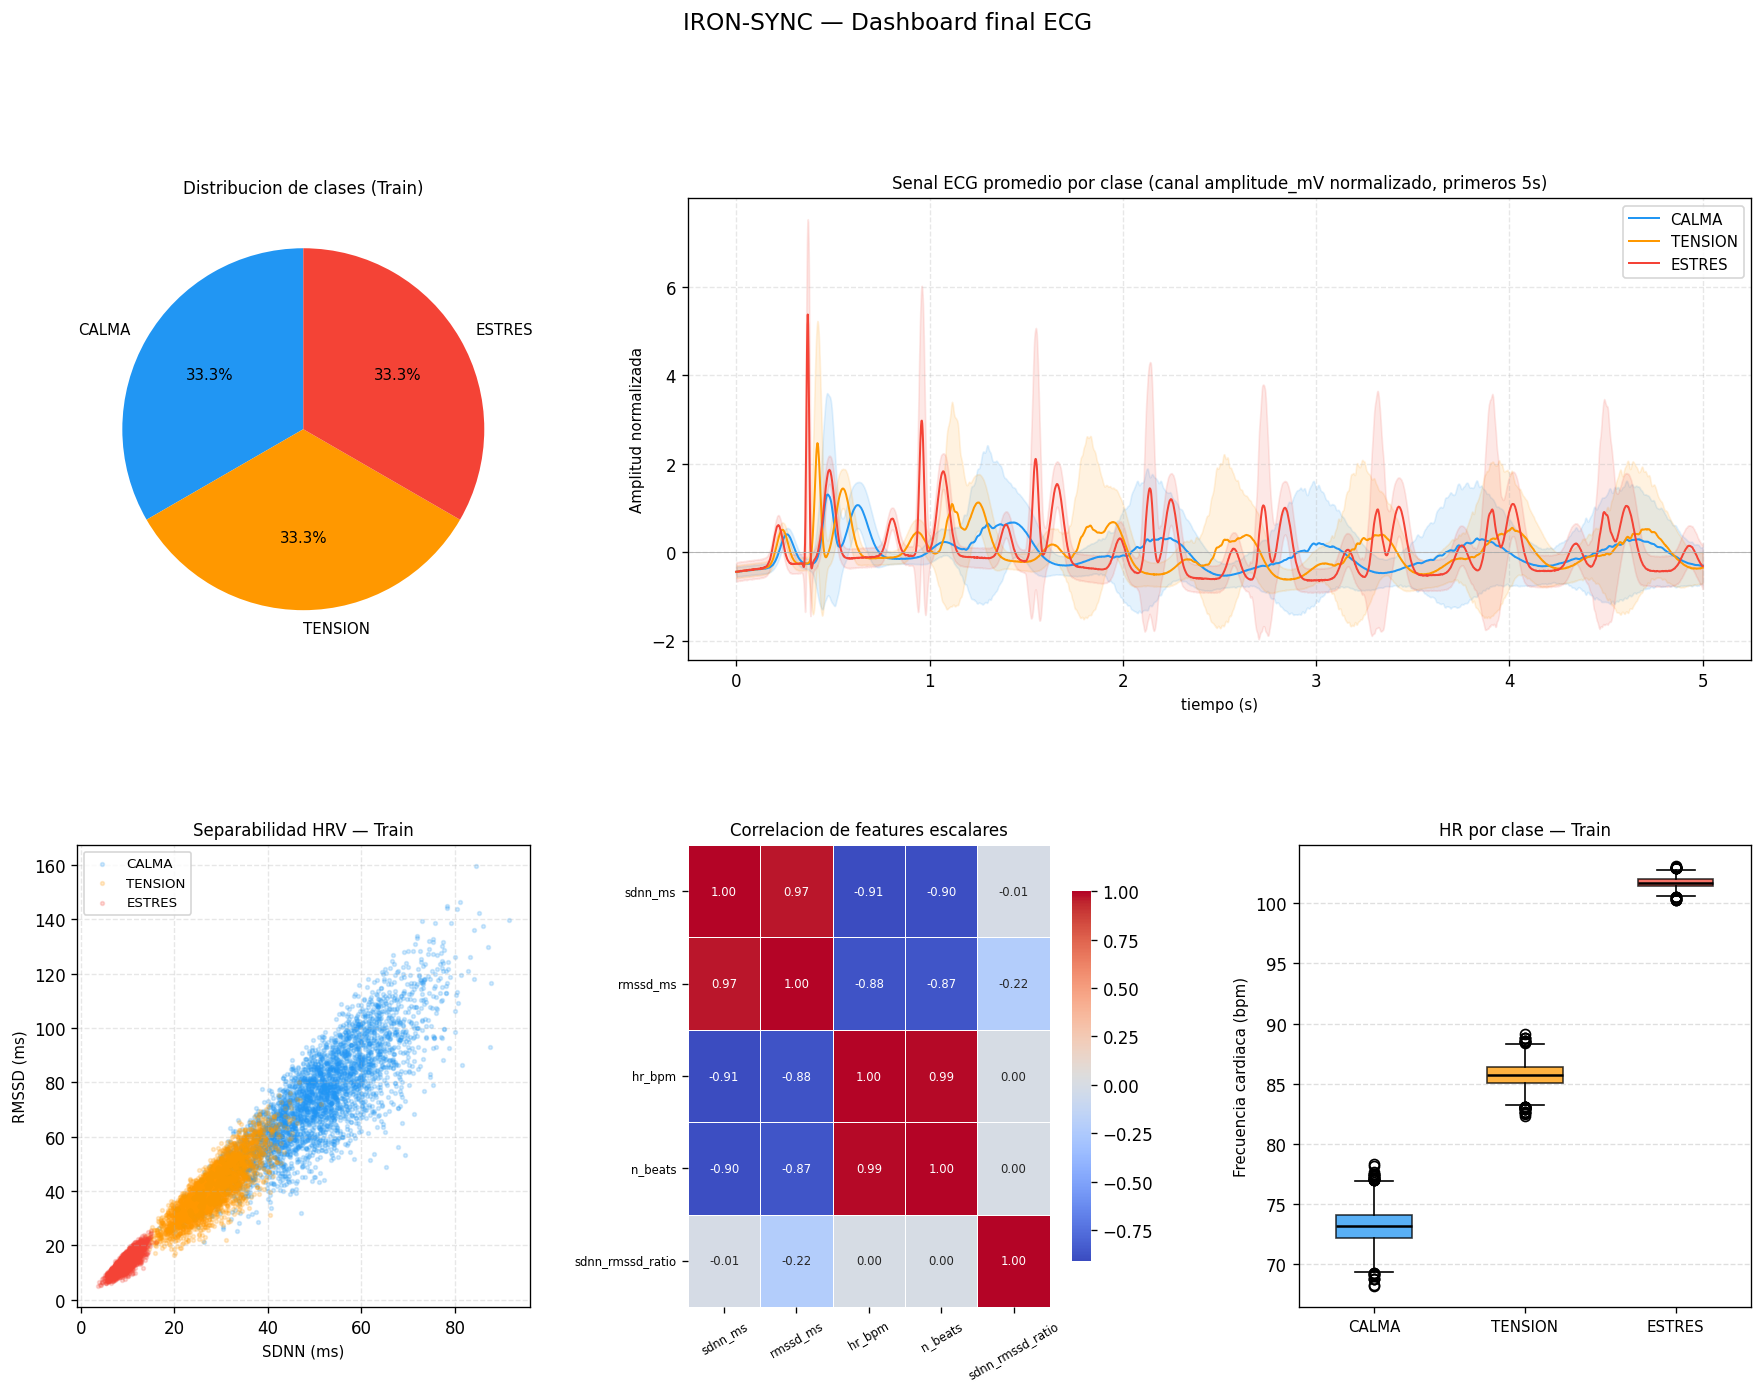

Dashboard guardado: ECG_dashboard_final.png


In [13]:
fig = plt.figure(figsize=(18, 12), dpi=120)
fig.suptitle("IRON-SYNC — Dashboard final ECG", fontsize=14, y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# --- Panel 1: Distribucion de clases en train ---
ax1 = fig.add_subplot(gs[0, 0])
conteos = [(y_train == v).sum() for v in LABEL_MAP.values()]
ax1.pie(conteos, labels=CLASES, colors=[COLORES[c] for c in CLASES],
        autopct="%1.1f%%", startangle=90,
        textprops={"fontsize": 9})
ax1.set_title("Distribucion de clases (Train)", fontsize=10)

# --- Panel 2: Senal promedio normalizada por clase ---
ax2 = fig.add_subplot(gs[0, 1:])
t_eje_5s = np.linspace(0, 5, FS * 5)
for clase in CLASES:
    idx_clase = np.where(y_train == LABEL_MAP[clase])[0]
    senales   = X_tensor_train[idx_clase, :FS*5, 0]  # canal 0 normalizado
    media     = senales.mean(axis=0)
    desvio    = senales.std(axis=0)
    ax2.plot(t_eje_5s, media, color=COLORES[clase], linewidth=1.2, label=clase)
    ax2.fill_between(t_eje_5s, media - desvio, media + desvio,
                     color=COLORES[clase], alpha=0.12)

ax2.set_title("Senal ECG promedio por clase (canal amplitude_mV normalizado, primeros 5s)", fontsize=10)
ax2.set_xlabel("tiempo (s)", fontsize=9)
ax2.set_ylabel("Amplitud normalizada", fontsize=9)
ax2.legend(fontsize=9)
ax2.grid(linestyle="--", alpha=0.3)
ax2.axhline(0, color="#AAAAAA", linewidth=0.5)

# --- Panel 3: Scatter SDNN vs RMSSD (train) ---
ax3 = fig.add_subplot(gs[1, 0])
for clase in CLASES:
    idx_c = np.where(y_train == LABEL_MAP[clase])[0]
    ax3.scatter(
        meta_train.iloc[idx_c]["sdnn_ms"],
        meta_train.iloc[idx_c]["rmssd_ms"],
        color=COLORES[clase], alpha=0.2, s=5, label=clase
    )
ax3.set_xlabel("SDNN (ms)", fontsize=9)
ax3.set_ylabel("RMSSD (ms)", fontsize=9)
ax3.set_title("Separabilidad HRV — Train", fontsize=10)
ax3.legend(fontsize=8)
ax3.grid(linestyle="--", alpha=0.3)

# --- Panel 4: Heatmap de correlacion de features escalares ---
ax4 = fig.add_subplot(gs[1, 1])
df_corr = pd.DataFrame(X_feat_train_n, columns=nombres_features)
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax4, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 7})
ax4.set_title("Correlacion de features escalares", fontsize=10)
ax4.tick_params(axis="x", rotation=30, labelsize=7)
ax4.tick_params(axis="y", rotation=0, labelsize=7)

# --- Panel 5: Boxplot HR por clase en train ---
ax5 = fig.add_subplot(gs[1, 2])
datos_hr = [meta_train[meta_train["clase"] == c]["hr_bpm"].values for c in CLASES]
bp = ax5.boxplot(datos_hr, patch_artist=True, widths=0.5,
                 medianprops=dict(color="black", linewidth=1.5))
for patch, clase in zip(bp["boxes"], CLASES):
    patch.set_facecolor(COLORES[clase])
    patch.set_alpha(0.75)
ax5.set_xticklabels(CLASES, fontsize=9)
ax5.set_ylabel("Frecuencia cardiaca (bpm)", fontsize=9)
ax5.set_title("HR por clase — Train", fontsize=10)
ax5.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig(FIGURES_PATH / "ECG_dashboard_final.png", dpi=120, bbox_inches="tight")
plt.show()
print("Dashboard guardado: ECG_dashboard_final.png")

## 14. Resumen del preprocesamiento

### Que se realizo en este cuadernillo

1. Verificacion de la estructura del dataset y conteo de archivos por clase.
2. Carga de 15000 archivos CSV con parseo de metadatos HRV de la cabecera.
3. Verificacion de integridad: NaN, Inf y longitud de senal.
4. Analisis exploratorio visual de senales y metricas HRV.
5. Extraccion de 5 features escalares por muestra (sdnn, rmssd, hr, n_beats, ratio).
6. Construccion del tensor multicanal de shape `(n, 5000, 4)`.
7. Division estratificada 70/15/15 con semilla fija.
8. Normalizacion z-score ajustada exclusivamente con datos de train.
9. Guardado de tensores `.npy`, metadatos `.csv` y scalers `.pkl`.

### Proximos pasos — Entrenamiento CNN-1D + LSTM

Cargar los arrays guardados e instanciar la arquitectura:

```python
import numpy as np

X_train = np.load("preprocessed/ECG/X_tensor_train.npy")   # (n, 5000, 4)
y_train = np.load("preprocessed/ECG/y_train.npy")

# Arquitectura objetivo:
# Conv1D(64, kernel=7, activation='relu') -> MaxPool1D(4)
# Conv1D(128, kernel=5, activation='relu') -> MaxPool1D(4)
# LSTM(64, return_sequences=False)
# Dense(64, activation='relu')
# Dense(3, activation='softmax')

# Objetivo de rendimiento: accuracy > 90%, F1-score macro > 0.90
```

### Archivos listos para entrenamiento

| Archivo                 | Shape        |
|-------------------------|--------------|
| X_tensor_train.npy      | (n, 5000, 4) |
| X_tensor_val.npy        | (n, 5000, 4) |
| X_tensor_test.npy       | (n, 5000, 4) |
| X_feat_train.npy        | (n, 5)       |
| y_train.npy             | (n,)         |
| scaler_ecg_signal.pkl   | —            |
| scaler_ecg_features.pkl | —            |